# 02. Гипотезы, статистическая значимость и sensitivity

Статистические сравнения делаются по одинаковым out-of-time блокам. Для парных lift используется односторонний Wilcoxon и поправка Holm. Продуктовые claims про понятность и лояльность отделены от проверяемых рыночных proxy.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
ROOT = Path('..') if Path.cwd().name == 'notebooks' else Path('.')
RESULTS = ROOT / 'results/hypothesis_study'
tests = pd.read_csv(RESULTS / 'statistical_tests.csv')
random_tests = pd.read_csv(RESULTS / 'model_vs_random_tests.csv')
verdicts = pd.read_csv(RESULTS / 'hypothesis_verdicts.csv')
proxies = pd.read_csv(RESULTS / 'proxy_hypothesis_tests.csv')
sensitivity = pd.read_csv(RESULTS / 'h_epsilon_summary.csv')
display(verdicts)
display(tests)
display(random_tests)
display(proxies)

,hypothesis,verdict,evidence,what_remains
0,H1 relative-format proxy,rejected_proxy,hit 67.4% vs 67.0%; Mann-Whitney p=0.589,Original understandability claim needs user re...
1,H2 combined factors,promising_not_confirmed,paired delta lift 0.312; raw p=0.03125; Holm p...,Need more independent test periods
2,H3 rarity/cooldown proxy,rejected_proxy,"precision delta -1.2%; CI [-5.4%, 3.0%]",Loyalty needs notification interaction logs
3,H4 pooled vs per-corridor,inconclusive,logistic delta lift 0.159; Holm p=1.000,Pooled random forest is the practical candidate
4,H5 fast vs slow,rejected_for_current_rule,slow-fast hit delta -0.8%; p=0.561,A different adaptive policy can be tested later
5,H6 honest UX and trust,not_testable,No user reaction data,Controlled message test or pilot
6,H7 CBR vs bank benefit,blocked_by_data,No historical bank rate/spread,Parallel bank and CBR time series
7,ML-H006 derivatives,rejected,median delta lift -0.001; Holm p=1.000,Keep only if a later fold shows stable gain
8,ML-H007 USD/EUR,inconclusive,"mean delta 0.215, median 0.041; Holm p=0.656",Effect is unstable and driven by a few folds


,hypothesis,n_time_blocks,left_mean_lift,right_mean_lift,mean_delta_lift,median_delta_lift,p_value_one_sided,p_value_holm,significant_5pct
0,H2 combination vs price-only,5,1.121753,1.434221,0.312468,0.370505,0.03125,0.12500,False
1,Derivatives vs case factors,5,1.434221,1.441339,0.007118,-0.000612,0.59375,1.00000,False
2,USD/EUR factors vs derivatives,5,1.398621,1.613122,0.214502,0.040978,0.21875,0.65625,False
3,H4 pooled vs per-corridor logistic,4,1.322807,1.482215,0.159408,-0.002142,0.56250,1.00000,False


,strategy,model,n_test_years,mean_yearly_lift,min_yearly_lift,p_value_one_sided,p_value_holm,significant_5pct
0,pooled_with_corridor_thresholds,random_forest,5,1.616072,1.181740,0.03125,0.375,False
1,pooled_with_corridor_thresholds,logistic,5,1.613122,1.058195,0.03125,0.375,False
2,per_corridor,random_forest,5,1.570979,1.053430,0.03125,0.375,False
3,pooled_with_corridor_thresholds,svm,5,1.518883,0.989399,0.06250,0.375,False
4,per_corridor,svm,5,1.486398,0.924079,0.06250,0.375,False
5,pooled_with_corridor_thresholds,catboost,5,1.479642,1.150783,0.03125,0.375,False
6,per_corridor,knn,5,1.434801,1.060915,0.03125,0.375,False
7,per_corridor,catboost,5,1.411563,1.167721,0.03125,0.375,False
8,pooled_with_corridor_thresholds,knn,5,1.344941,1.053824,0.03125,0.375,False
9,per_corridor,logistic,5,1.315608,1.082873,0.03125,0.375,False


,hypothesis,selected_days,other_days,selected_hit_rate,other_hit_rate,selected_regret_bps_median,other_regret_bps_median,mann_whitney_p,odds_ratio_hit,fisher_p,...,precision_before,precision_after,precision_delta,bootstrap_ci_low,bootstrap_ci_high,paired_folds,mean_hit_delta_slow_minus_fast,p_value_one_sided,mean_wait_days,mean_waiting_cost_bps
0,H1 relative-format market proxy,3243.0,8784.0,0.674067,0.669854,13.07155,13.45321,0.588721,1.019296,0.3396,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,H3 rarity/cooldown proxy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.804065,0.792537,-0.011528,-0.053745,0.029573,NaN,NaN,NaN,NaN,NaN
2,H5 fast-vs-slow proxy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,19.0,-0.007654,0.560575,1.009569,7.25515


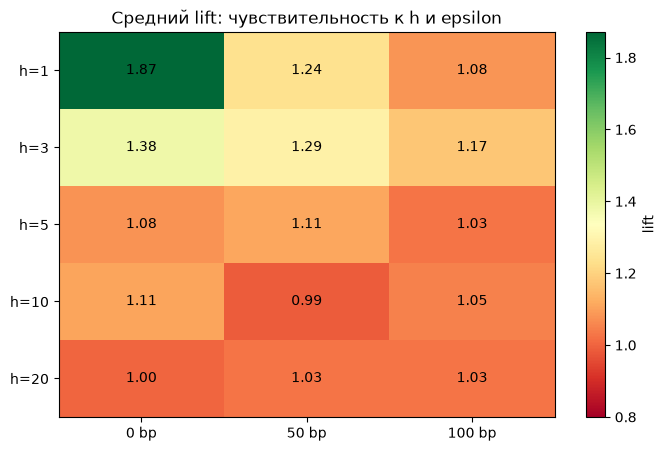

In [2]:
view = sensitivity[sensitivity['strategy'] == 'pooled_with_corridor_thresholds']
heat = view.pivot(index='horizon_days', columns='epsilon_bps', values='mean_lift')
fig, ax = plt.subplots(figsize=(8, 5))
image = ax.imshow(heat.values, cmap='RdYlGn', aspect='auto', vmin=0.8, vmax=max(1.4, heat.max().max()))
ax.set_xticks(range(len(heat.columns)), [f'{x} bp' for x in heat.columns])
ax.set_yticks(range(len(heat.index)), [f'h={x}' for x in heat.index])
for y in range(len(heat.index)):
    for x in range(len(heat.columns)):
        ax.text(x, y, f'{heat.iloc[y, x]:.2f}', ha='center', va='center')
ax.set_title('Средний lift: чувствительность к h и epsilon')
fig.colorbar(image, ax=ax, label='lift')
plt.show()

In [3]:
display(sensitivity.sort_values(['mean_lift', 'worst_fold_lift'], ascending=False).head(20))

,horizon_days,epsilon_bps,strategy,mean_lift,mean_hit_rate,mean_frequency,worst_fold_lift,mean_advantage_bps,mean_regret_bps
0,1,0,pooled_with_corridor_thresholds,1.871327,0.971484,0.834223,1.628549,1.951950,1.003298
1,1,0,per_corridor,1.786804,0.942390,0.780704,1.319395,2.046087,3.629375
2,3,0,pooled_with_corridor_thresholds,1.379763,0.553677,0.597406,0.000000,3.603069,27.654999
3,3,0,per_corridor,1.355911,0.541526,0.477447,0.791655,6.138987,36.993922
4,3,50,per_corridor,1.301586,0.799904,0.656298,0.819030,13.614960,31.659610
5,3,50,pooled_with_corridor_thresholds,1.288594,0.794355,0.694364,0.900785,9.267346,32.001943
6,5,0,per_corridor,1.237019,0.422811,0.552676,0.000000,7.076599,80.818135
7,1,50,pooled_with_corridor_thresholds,1.235540,0.971740,0.693204,1.032347,0.258624,3.741705
8,1,50,per_corridor,1.217805,0.951005,0.773687,1.000000,-0.534612,6.651023
9,10,0,per_corridor,1.208833,0.280905,0.520687,0.000000,7.507294,188.251523


## Граница выводов

H6 про доверие и H7 про соответствие курсу приложения нельзя подтвердить на котировках ЦБ. Для H6 нужны user research или логи взаимодействия; для H7 — параллельный исторический банковский курс и спред. Рублёвый эквивалент advantage/regret в отчёте — сценарная оценка для 100 000 ₽, а не измеренная экономия клиента.